In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
file_gaji = "Rata-rata Upah_Gaji Bersih Sebulan Buruh_Karyawan_Pegawai Menurut Provinsi dan Jenis Pekerjaan Utama, 2025.csv"
file_pengeluaran = "Rata‑Rata Pengeluaran per Kapita Sebulan Untuk Makanan dan Bukan Makanan di Daerah Perkotaan dan Perdesaan Menurut Provinsi (rupiah), 2011-2025.csv"

df_gaji_raw = pd.read_csv(file_gaji, header=None, skiprows=5)
df_gaji = df_gaji_raw[[0, 2]].copy()
df_gaji.columns = ['Provinsi', 'Gaji_Profesional']

df_exp_raw = pd.read_csv(file_pengeluaran, header=None, skiprows=4)
df_exp = df_exp_raw[[0, 45]].copy()
df_exp.columns = ['Provinsi', 'Exp_Total_BPS']

print("Data Loaded.")
print(f"Jumlah Baris Gaji: {len(df_gaji)}")
print(f"Jumlah Baris Pengeluaran: {len(df_exp)}")

Data Loaded.
Jumlah Baris Gaji: 39
Jumlah Baris Pengeluaran: 47


In [3]:
# Fungsi pembersih angka
def clean_currency(x):
    if isinstance(x, str):
        # Hapus spasi, koma, dan tanda strip
        x = x.replace(',', '').replace(' ', '').replace('-', '0').strip()
        if x == '': return 0
    return pd.to_numeric(x)

# Terapkan ke kolom angka
df_gaji['Gaji_Profesional'] = df_gaji['Gaji_Profesional'].apply(clean_currency)
df_exp['Exp_Total_BPS'] = df_exp['Exp_Total_BPS'].apply(clean_currency)

# Hapus baris kosong (biasanya footer BPS)
df_gaji = df_gaji.dropna(subset=['Provinsi'])
df_exp = df_exp.dropna(subset=['Provinsi'])

# Standarisasi Nama Provinsi untuk Merging (Join Key)
def standardize_prov(name):
    name = str(name).upper().strip()
    name = name.replace("DKI ", "").replace("DI ", "").replace("DAERAH ISTIMEWA ", "")
    name = name.replace("KEP. ", "KEPULAUAN ").replace("BANGKA BELITUNG", "KEPULAUAN BANGKA BELITUNG")
    return name

df_gaji['Key'] = df_gaji['Provinsi'].apply(standardize_prov)
df_exp['Key'] = df_exp['Provinsi'].apply(standardize_prov)

# Merge Data (Inner Join)
df_main = pd.merge(df_gaji, df_exp[['Key', 'Exp_Total_BPS']], on='Key', how='inner')

print(f"Data Bersih Siap Analisis: {len(df_main)} Provinsi")
df_main.head()

Data Bersih Siap Analisis: 37 Provinsi


,Provinsi,Gaji_Profesional,Key,Exp_Total_BPS
0,ACEH,2981520,ACEH,1299756.0
1,SUMATERA UTARA,3214099,SUMATERA UTARA,1397887.0
2,SUMATERA BARAT,3547621,SUMATERA BARAT,1542109.0
3,RIAU,3804879,RIAU,1610427.0
4,JAMBI,3409725,JAMBI,1477104.0


In [4]:
# --- PARAMETER ASUMSI ---
TARGET_DP_RUMAH = 100000000  # Target Tabungan 100 Juta
LIFESTYLE_AVG_FACTOR = 1.5   # Kenaikan 50% dari BPS (Kost AC, Ngopi)
LIFESTYLE_BAD_FACTOR = 2.5   # Kenaikan 150% dari BPS (Apartemen, Mobil)

# 1. BEST WAY (Scenario Hemat / BPS Baseline)
df_main['Savings_Best'] = df_main['Gaji_Profesional'] - df_main['Exp_Total_BPS']

# 2. AVERAGE WAY (Scenario Normal Gen Z)
df_main['Exp_Avg'] = df_main['Exp_Total_BPS'] * LIFESTYLE_AVG_FACTOR
df_main['Savings_Avg'] = df_main['Gaji_Profesional'] - df_main['Exp_Avg']

# 3. BAD WAY (Scenario Boros)
df_main['Exp_Bad'] = df_main['Exp_Total_BPS'] * LIFESTYLE_BAD_FACTOR
df_main['Savings_Bad'] = df_main['Gaji_Profesional'] - df_main['Exp_Bad']

# Hitung "Tahun Menabung Rumah" (Years to House)
# Rumus: 100 Juta / (Tabungan Bulanan * 12)
# Jika tabungan minus/nol, kita set angka tinggi (999) agar tidak error
def calc_years(savings):
    if savings <= 0: return 999
    return TARGET_DP_RUMAH / (savings * 12)

df_main['Years_Best'] = df_main['Savings_Best'].apply(calc_years)
df_main['Years_Avg'] = df_main['Savings_Avg'].apply(calc_years)
df_main['Years_Bad'] = df_main['Savings_Bad'].apply(calc_years)

# Urutkan berdasarkan performa "Average Way" (Paling realistis)
df_rank = df_main.sort_values('Savings_Avg', ascending=False).reset_index(drop=True)

print("Top 5 Provinsi Paling Cuan (Skenario Normal):")
print(df_rank[['Provinsi', 'Gaji_Profesional', 'Savings_Avg', 'Years_Avg']].head())

Top 5 Provinsi Paling Cuan (Skenario Normal):
        Provinsi  Gaji_Profesional  Savings_Avg  Years_Avg
0    DKI JAKARTA           7421972    2978354.0   2.797966
1   PAPUA TENGAH           4949162    2760530.0   3.018744
2         BANTEN           5290622    2664803.0   3.127186
3  PAPUA SELATAN           4650519    2374390.5   3.509673
4     JAWA BARAT           4826039    2239488.5   3.721088


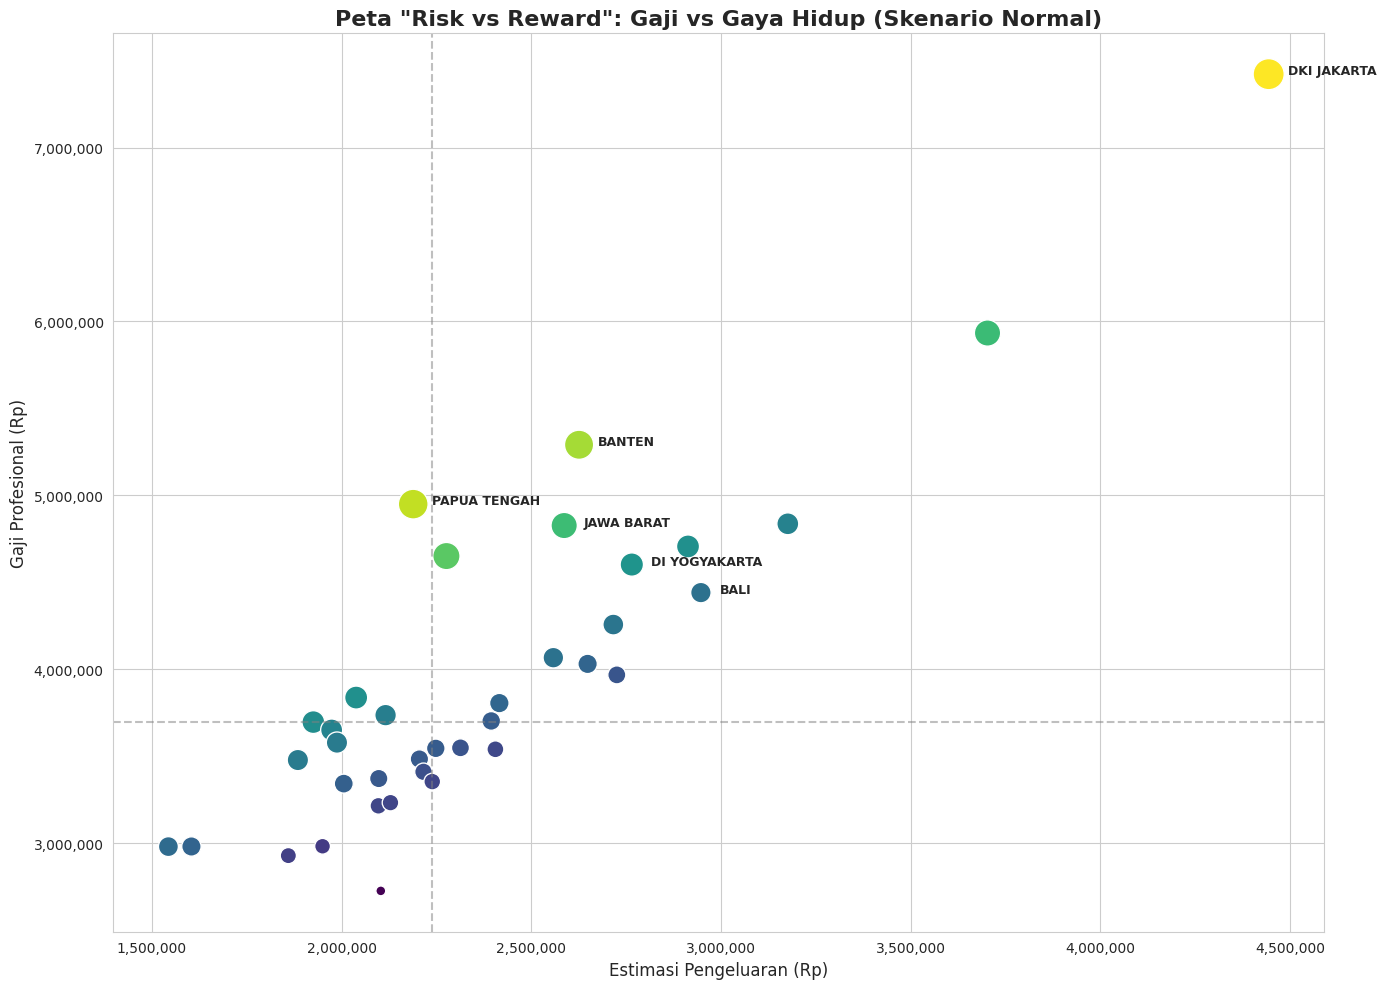

In [5]:
plt.figure(figsize=(14, 10))

# Scatter Plot
sns.scatterplot(data=df_rank, x='Exp_Avg', y='Gaji_Profesional',
                size='Savings_Avg', sizes=(50, 500),
                hue='Savings_Avg', palette='viridis', legend=False)

# Garis Median (Kuadran)
plt.axvline(x=df_rank['Exp_Avg'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df_rank['Gaji_Profesional'].median(), color='gray', linestyle='--', alpha=0.5)

# Labeling Provinsi Penting
provinces_to_label = ['DKI JAKARTA', 'BANTEN', 'DI YOGYAKARTA', 'BALI', 'PAPUA TENGAH', 'JAWA BARAT']
for i, row in df_rank.iterrows():
    if row['Provinsi'] in provinces_to_label or row['Savings_Avg'] > 3000000:
        plt.text(row['Exp_Avg']+50000, row['Gaji_Profesional'], row['Provinsi'], fontsize=9, weight='bold')

# Dekorasi
plt.title('Peta "Risk vs Reward": Gaji vs Gaya Hidup (Skenario Normal)', fontsize=16, fontweight='bold')
plt.xlabel('Estimasi Pengeluaran (Rp)', fontsize=12)
plt.ylabel('Gaji Profesional (Rp)', fontsize=12)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

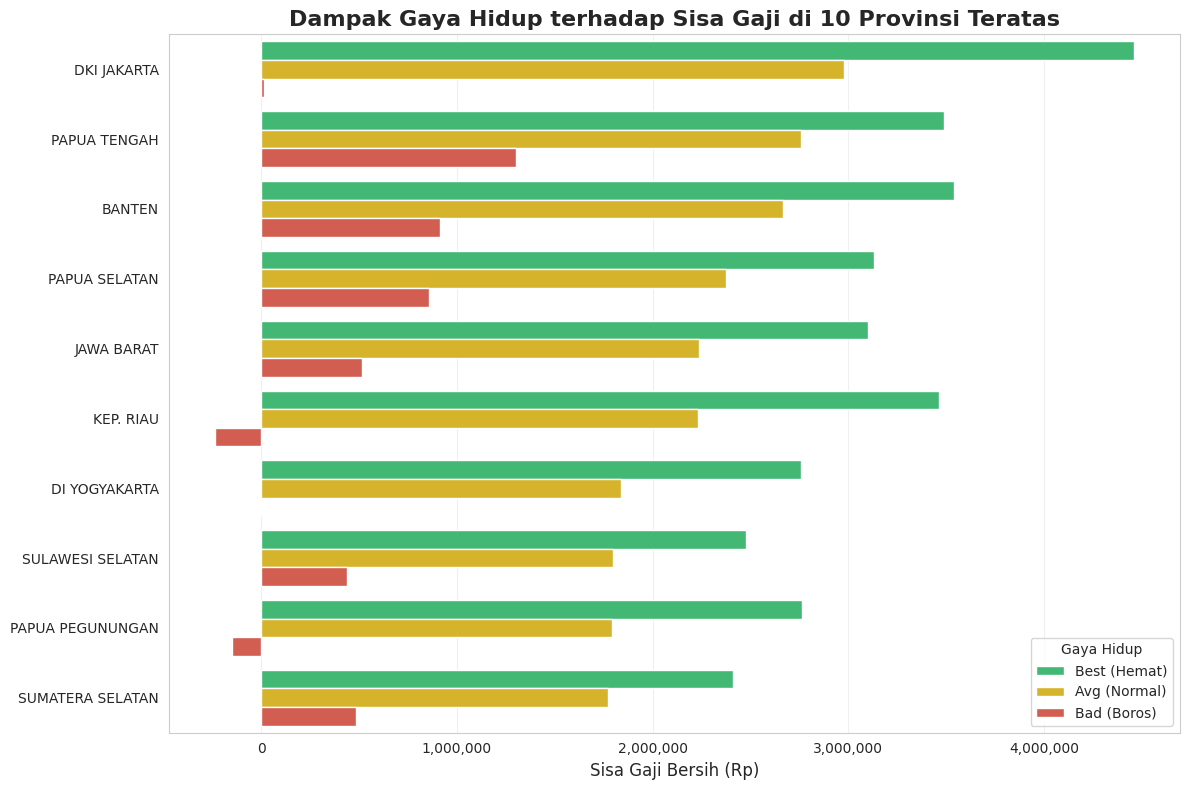

In [6]:
# Siapkan data untuk plotting (Melt)
df_top10 = df_rank.head(10).copy()
df_melt = df_top10.melt(id_vars=['Provinsi'],
                        value_vars=['Savings_Best', 'Savings_Avg', 'Savings_Bad'],
                        var_name='Scenario', value_name='Sisa_Gaji')

df_melt['Scenario'] = df_melt['Scenario'].map({
    'Savings_Best': 'Best (Hemat)',
    'Savings_Avg': 'Avg (Normal)',
    'Savings_Bad': 'Bad (Boros)'
})

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melt, x='Sisa_Gaji', y='Provinsi', hue='Scenario', palette=['#2ecc71', '#f1c40f', '#e74c3c'])

plt.title('Dampak Gaya Hidup terhadap Sisa Gaji di 10 Provinsi Teratas', fontsize=16, fontweight='bold')
plt.xlabel('Sisa Gaji Bersih (Rp)', fontsize=12)
plt.ylabel(None)
plt.legend(title='Gaya Hidup')
plt.grid(axis='x', alpha=0.3)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

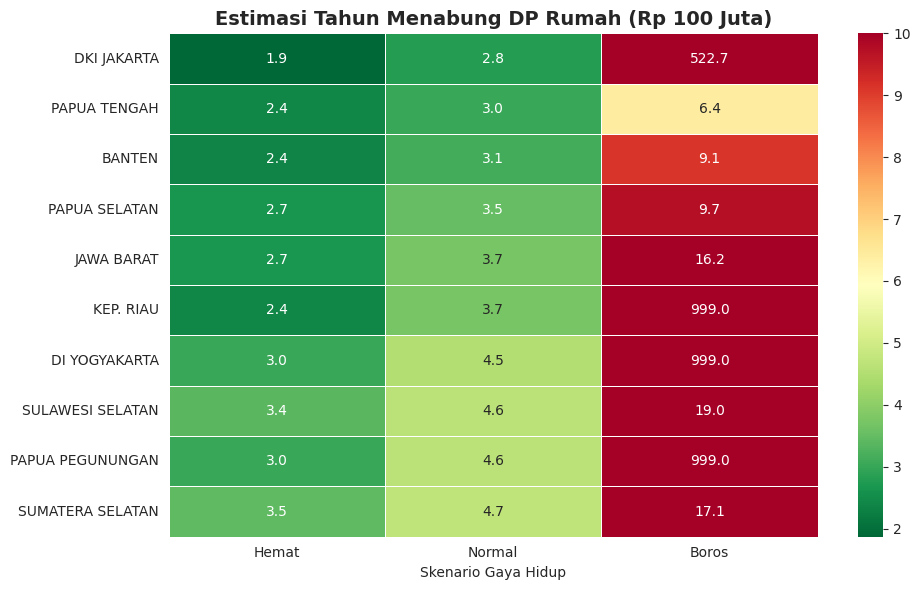

In [7]:
# Siapkan data heatmap
df_heatmap = df_top10.set_index('Provinsi')[['Years_Best', 'Years_Avg', 'Years_Bad']]
df_heatmap.columns = ['Hemat', 'Normal', 'Boros']

plt.figure(figsize=(10, 6))
# Clip data di 20 tahun biar warnanya gak rusak gara-gara outlier 999 tahun
sns.heatmap(df_heatmap, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=.5, vmax=10)

plt.title('Estimasi Tahun Menabung DP Rumah (Rp 100 Juta)', fontsize=14, fontweight='bold')
plt.xlabel('Skenario Gaya Hidup')
plt.ylabel(None)

plt.tight_layout()
plt.show()

In [8]:
best_prov = df_rank.iloc[0]
jakarta = df_rank[df_rank['Provinsi'] == 'DKI JAKARTA'].iloc[0]

print("--- AUTOMATED INSIGHT ---")
print(f"1. Provinsi Paling Cuan (Normal Mode): {best_prov['Provinsi']}")
print(f"   Gaji: Rp {best_prov['Gaji_Profesional']:,} | Sisa Tabungan: Rp {best_prov['Savings_Avg']:,}")
print(f"2. Posisi Jakarta:")
print(f"   Jika Hemat: Nabung Rp {jakarta['Savings_Best']:,}/bulan")
print(f"   Jika Boros (Bad Way): Sisa Gaji tinggal Rp {jakarta['Savings_Bad']:,}/bulan (Hati-hati!)")

--- AUTOMATED INSIGHT ---
1. Provinsi Paling Cuan (Normal Mode): DKI JAKARTA
   Gaji: Rp 7,421,972 | Sisa Tabungan: Rp 2,978,354.0
2. Posisi Jakarta:
   Jika Hemat: Nabung Rp 4,459,560.0/bulan
   Jika Boros (Bad Way): Sisa Gaji tinggal Rp 15,942.0/bulan (Hati-hati!)
